In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [65]:
data_ = pd.read_csv('netflix.csv')
data_.head(10) 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


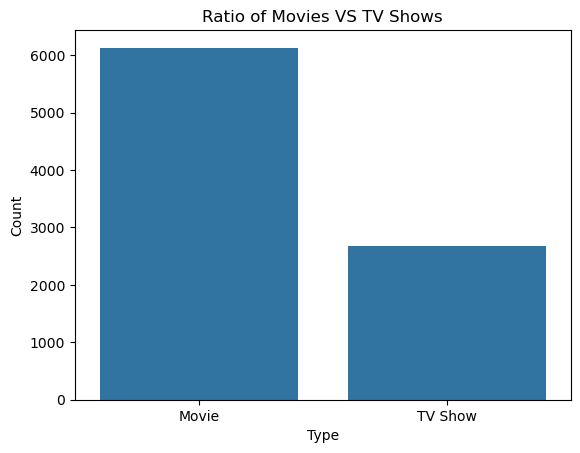

In [66]:
# 1)CONTENT STRATEGY

# 1.Ratio of TV Shows vs Movies

plt.Figure(figsize=(4, 2))
sns.countplot(data= data_, x='type')
plt.title("Ratio of Movies VS TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

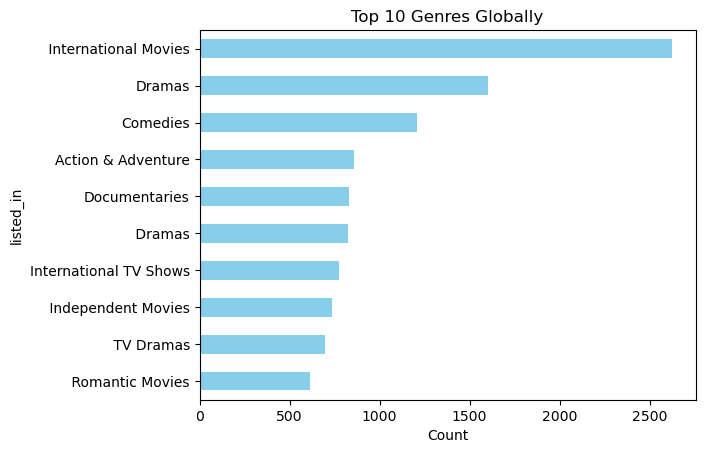

In [67]:
# 2. Most Popular Genres Globally

genre = data_['listed_in'].str.split(',').explode()
plt.Figure(figsize= (12, 8))
genre.value_counts().head(10).sort_values().plot(kind= 'barh', color = 'skyblue')
plt.title("Top 10 Genres Globally")
plt.xlabel("Count")
plt.show()

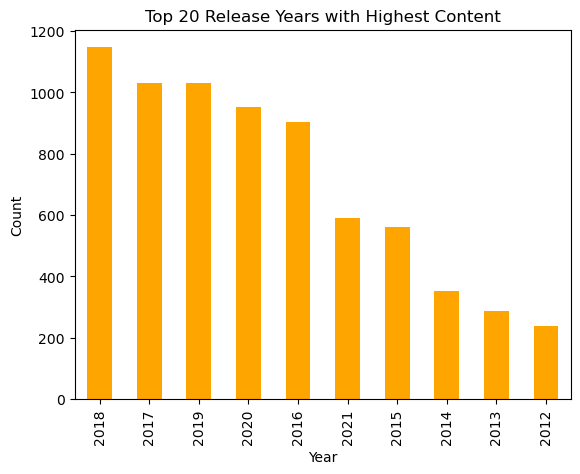

In [68]:
# 3. Years with highest releases

plt.Figure(figsize=(12, 6))
data_['release_year'].value_counts().head(10).sort_values(ascending= False).plot(kind = 'bar', color = 'orange')
plt.title("Top 20 Release Years with Highest Content")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

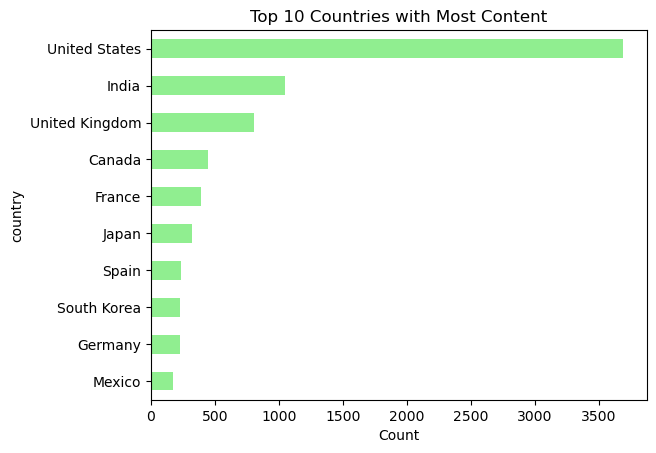

In [69]:
# 4. Countries producing the most Netflix Content

countries = data_['country'].str.split(', ').explode()
plt.Figure(figsize= (12, 8))
countries.value_counts().head(10).sort_values().plot(kind= 'barh', color = 'lightgreen')
plt.title("Top 10 Countries with Most Content")
plt.xlabel("Count")
plt.show()

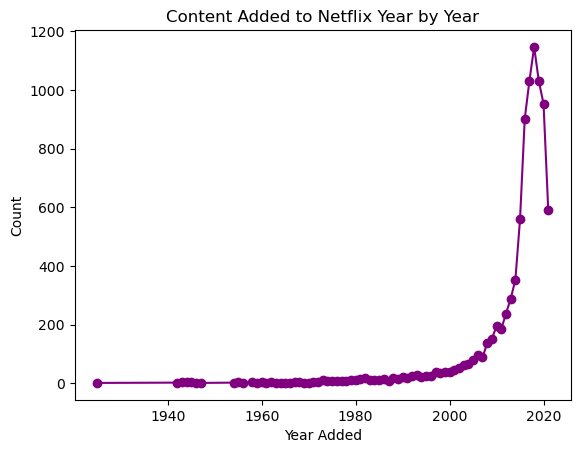

In [70]:
# 5. Trend of adding New Content year by year

plt.Figure(figsize= (12, 6))
data_['release_year'].value_counts().sort_index().plot(kind = 'line', marker = 'o', color = 'purple')
plt.title("Content Added to Netflix Year by Year")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.show()

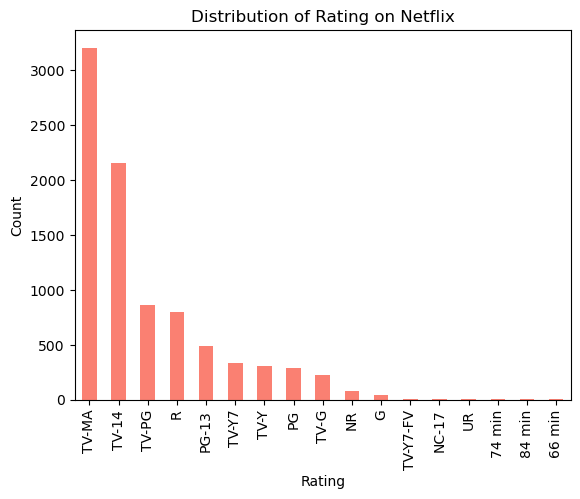

In [71]:
# 2) USER DEMOGRAPLICS & TARGETING

# 6. Frequent Rating

plt.Figure(figsize=(12, 6))
data_['rating'].value_counts().plot(kind= 'bar', color = 'salmon')
plt.title("Distribution of Rating on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

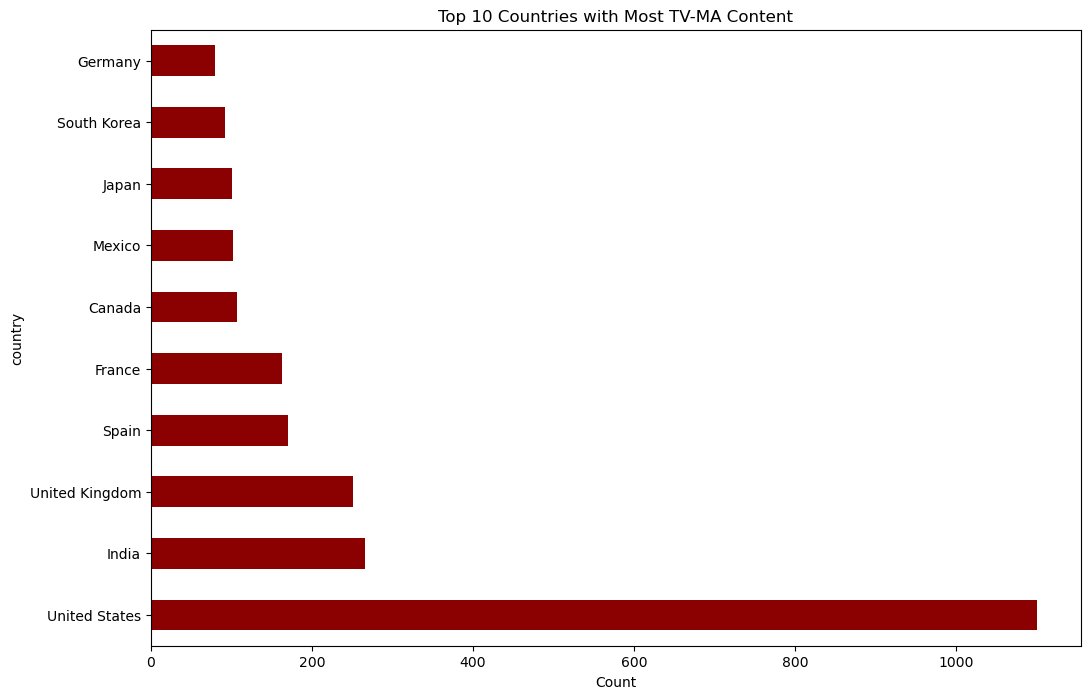

In [72]:
# 7. Mature content (TV-MA) by country

tv_ma_content = data_[data_['rating'] == 'TV-MA']
tv_ma_by_country = tv_ma_content['country'].str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(12, 8))
tv_ma_by_country.plot(kind= 'barh', color = 'darkred')
plt.title("Top 10 Countries with Most TV-MA Content")
plt.xlabel("Count")
plt.show()

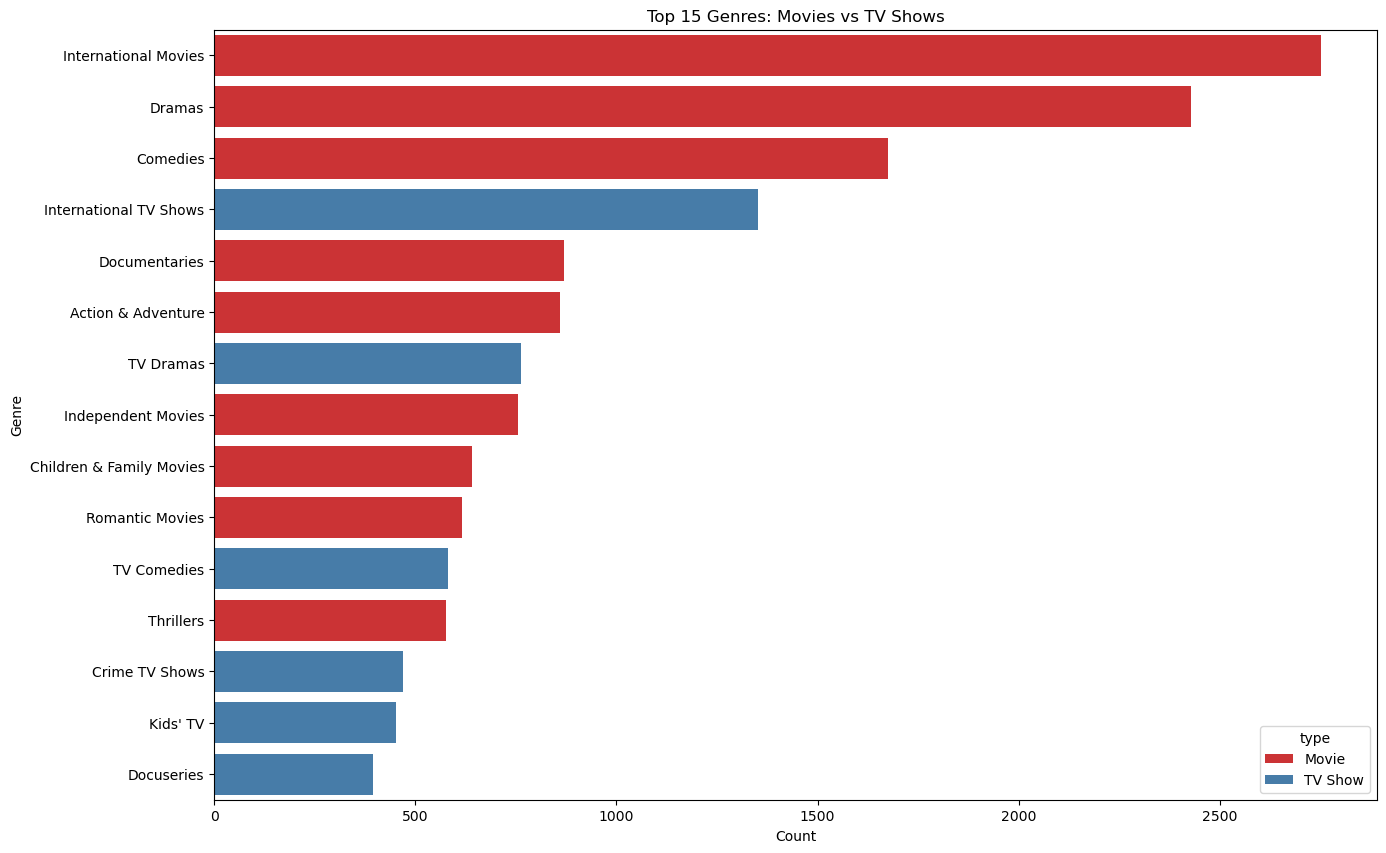

In [73]:
# 8. Genres associated with TV Shows vs Movies


genre_by_type = data_[['type', 'listed_in']]
genre_by_type = genre_by_type.assign(listed_in=genre_by_type['listed_in'].str.split(', ')).explode('listed_in')

top_15_genres = genre_by_type['listed_in'].value_counts().head(15).index

filtered_data = genre_by_type[genre_by_type['listed_in'].isin(top_15_genres)]

plt.figure(figsize=(15, 10))
sns.countplot(data=filtered_data, y='listed_in', hue='type', palette='Set1', order=top_15_genres)
plt.title('Top 15 Genres: Movies vs TV Shows')
plt.ylabel('Genre')
plt.xlabel('Count')
plt.show()

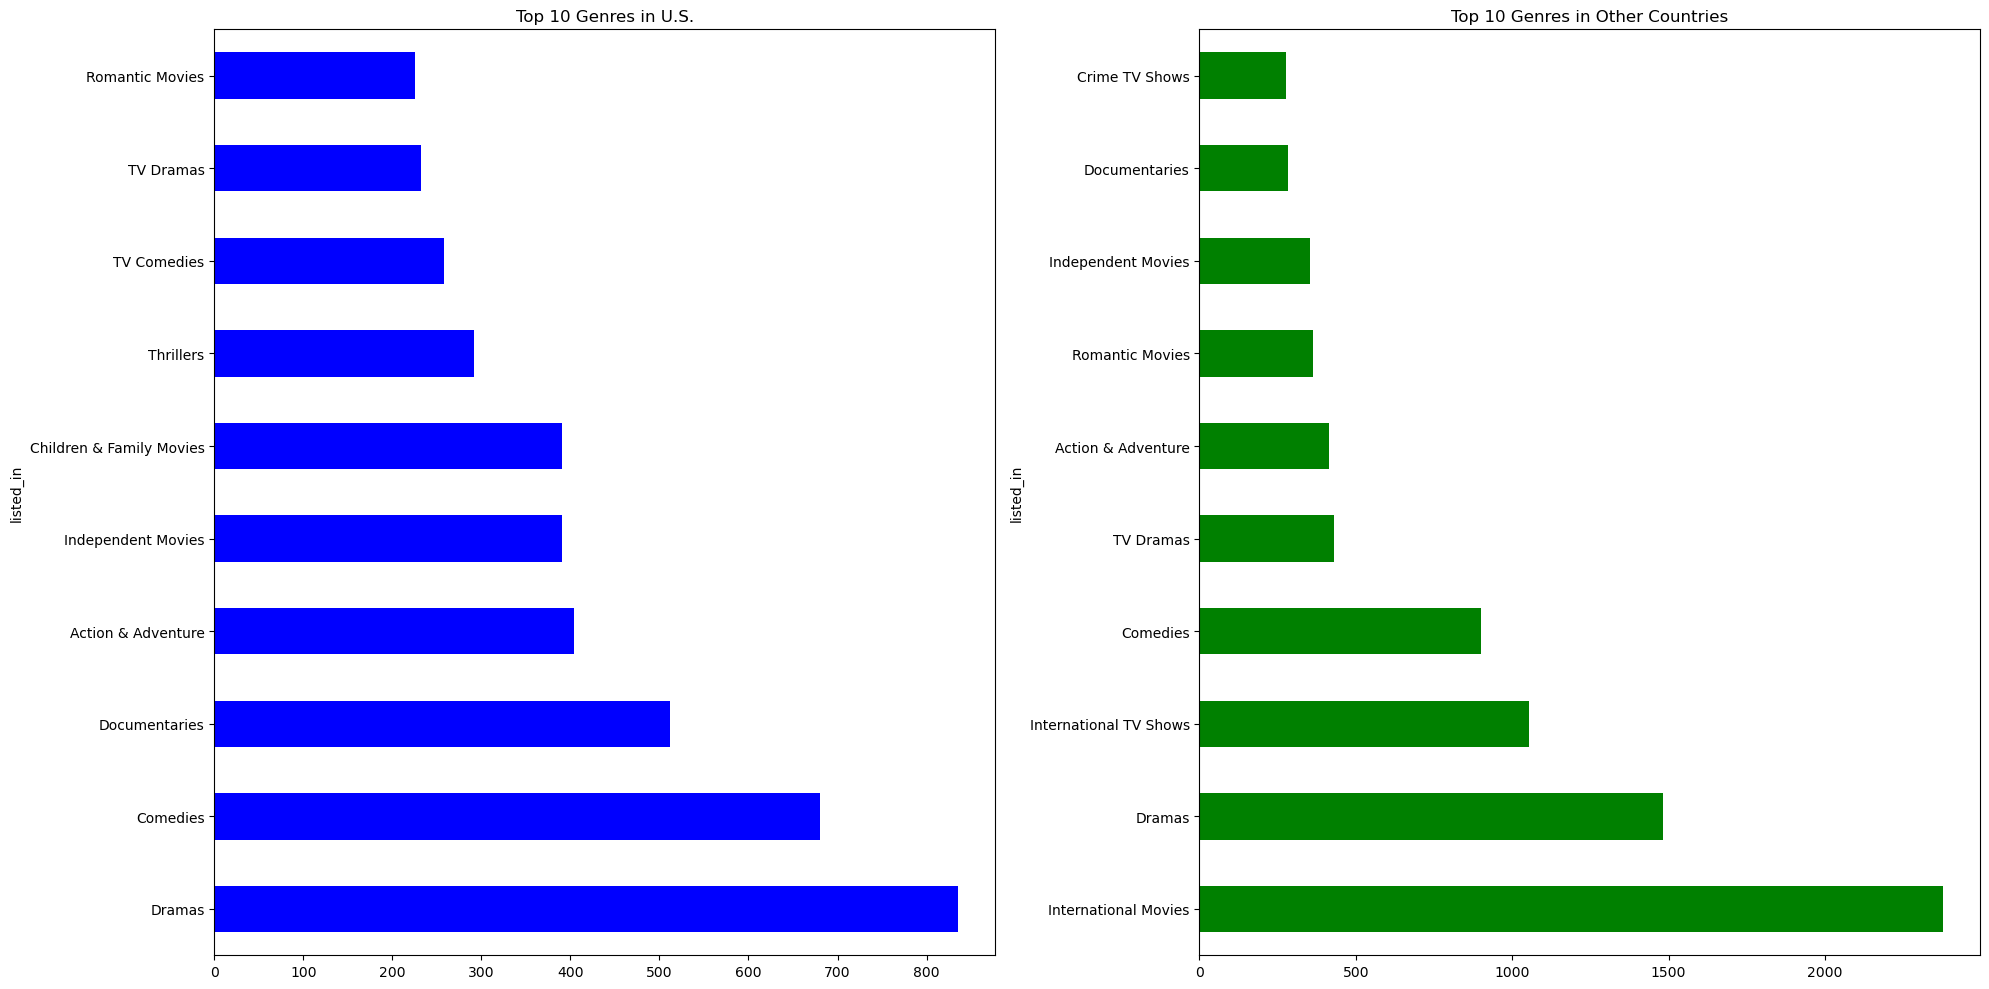

In [74]:
# 9. Genres in U.S vs Other Countries

us_vs_others = data_[['country', 'listed_in']].dropna()
us_vs_others['is_us'] = us_vs_others['country'].str.contains('United States')
us_vs_others = us_vs_others.assign(listed_in = us_vs_others['listed_in'].str.split(', ')).explode('listed_in')
top_genres_us = us_vs_others[us_vs_others['is_us'] == True]['listed_in'].value_counts().head(10)
top_genres_non_us = us_vs_others[us_vs_others['is_us'] == False]['listed_in'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
top_genres_us.plot(kind='barh', ax=axes[0], color='blue', title='Top 10 Genres in U.S.')
top_genres_non_us.plot(kind='barh', ax=axes[1], color='green', title='Top 10 Genres in Other Countries')
plt.tight_layout()
plt.show()

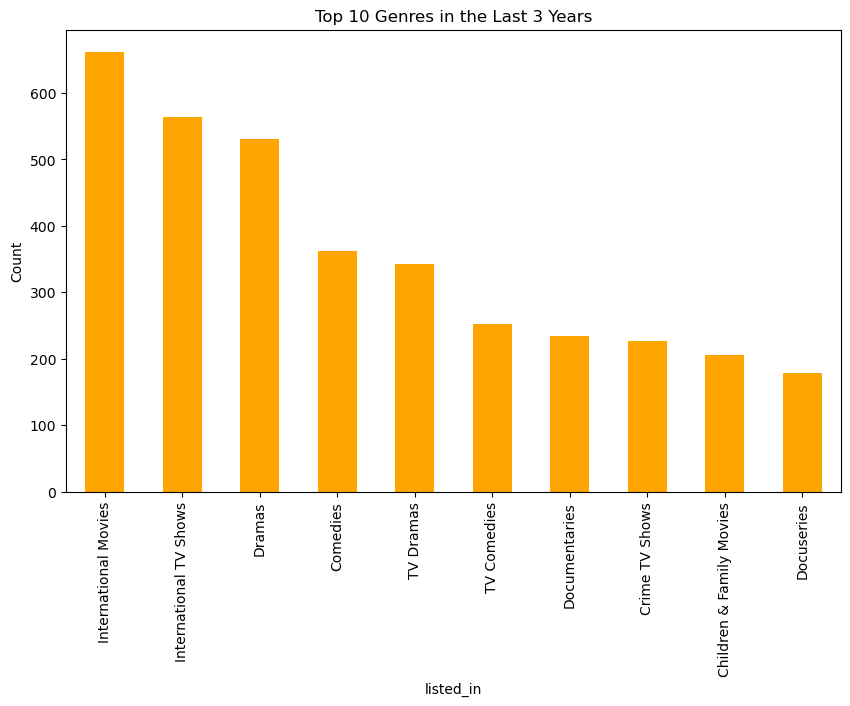

In [75]:
# 10. Genres popular in last 3 years

last_3_years = data_[data_['release_year'] >= (data_['release_year'].max() - 2)]
genres_last_3 = last_3_years['listed_in'].str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(10, 6))
genres_last_3.plot(kind='bar', color='orange')
plt.title('Top 10 Genres in the Last 3 Years')
plt.ylabel('Count')
plt.show()

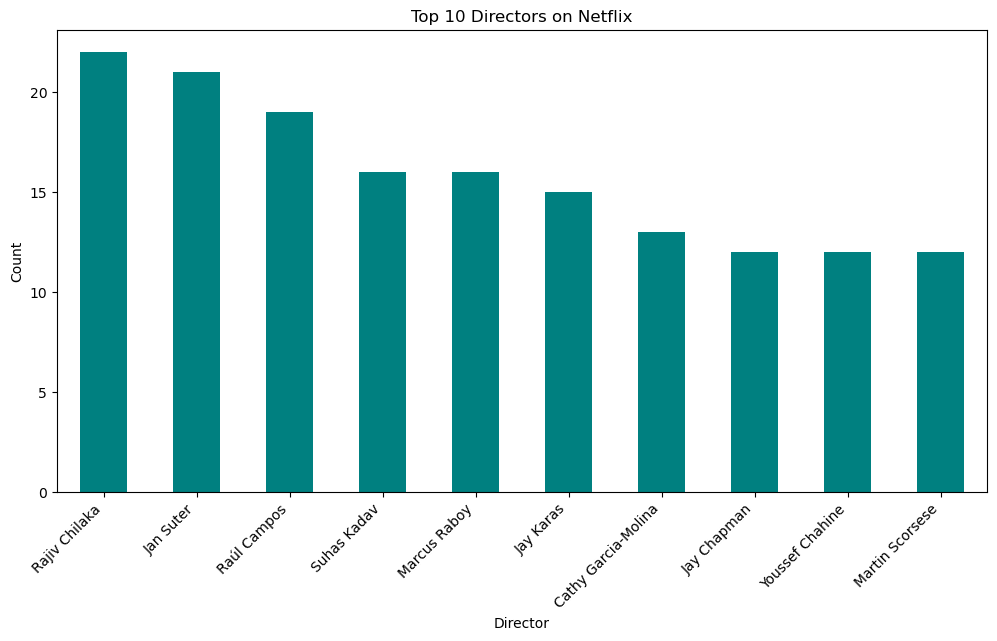

In [76]:
# 3) Talent Acuisition & Partnership

#  11. Top 10 directors

directors = data_['director'].dropna().str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(12, 6))
directors.plot(kind='bar', color='teal')
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

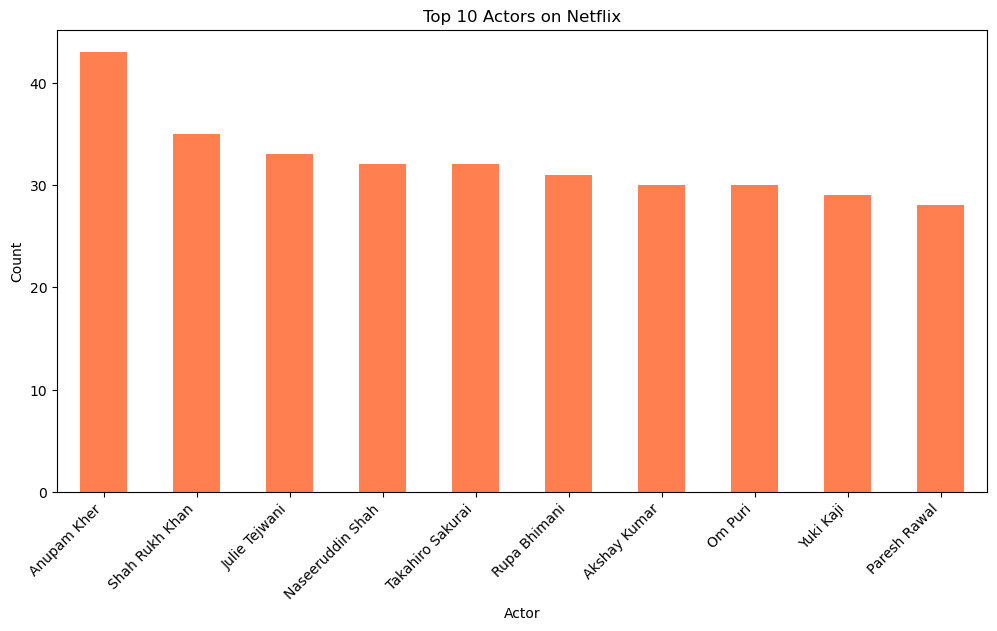

In [77]:
# 12. Most frequent actors

actors = data_['cast'].dropna().str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(12, 6))
actors.plot(kind='bar', color='coral')
plt.title('Top 10 Actors on Netflix')
plt.xlabel('Actor')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

In [78]:
# 13. Director-genre pairs

director_genre = data_[['director', 'listed_in']].dropna()
director_genre = director_genre.assign(director=director_genre['director'].str.split(', ')).explode('director')
director_genre = director_genre.assign(listed_in=director_genre['listed_in'].str.split(', ')).explode('listed_in')
pair_counts = director_genre.groupby(['director', 'listed_in']).size().reset_index(name='count').sort_values(by='count', ascending=False).head(10)
print("Top 10 Director-Genre Pairs:")
print(pair_counts)

Top 10 Director-Genre Pairs:
                  director                 listed_in  count
8969         Rajiv Chilaka  Children & Family Movies     22
4553             Jan Suter           Stand-Up Comedy     21
9107           Raúl Campos           Stand-Up Comedy     19
10736          Suhas Kadav  Children & Family Movies     16
6817          Marcus Raboy           Stand-Up Comedy     15
4675             Jay Karas           Stand-Up Comedy     14
1839   Cathy Garcia-Molina      International Movies     13
4666           Jay Chapman           Stand-Up Comedy     12
11949      Youssef Chahine                    Dramas     12
11951      Youssef Chahine      International Movies     10


In [79]:
# 14. Unknown directors or cast members

unknown_directors = data_['director'].isna().sum()
unknown_cast = data_['cast'].isna().sum()
print(f"Unknown directors: {unknown_directors}")
print(f"Unknown cast: {unknown_cast}")

Unknown directors: 2634
Unknown cast: 825


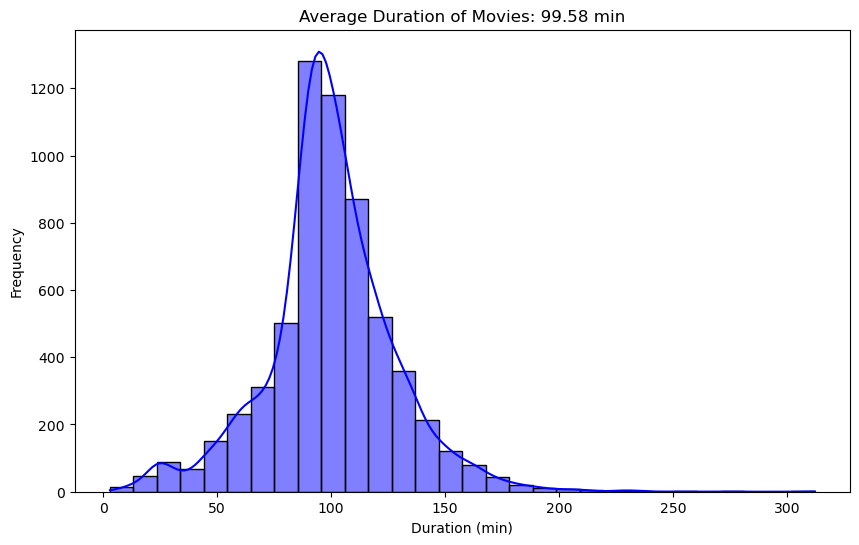

In [80]:
# 4) Duration & Engagement

# 15. Average duration of Movies

movies = data_[data_['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(float)
avg_duration = movies['duration_min'].mean()
plt.figure(figsize=(10, 6))
sns.histplot(movies['duration_min'], bins=30, kde=True, color='blue')
plt.title(f'Average Duration of Movies: {avg_duration:.2f} min')
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

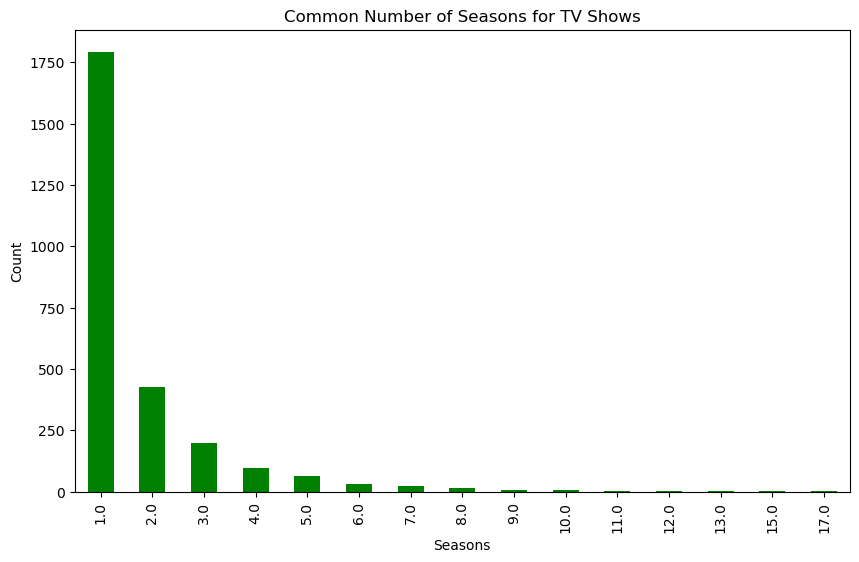

In [81]:
# 16. Most common number of seasons for TV shows

tv_shows = data_[data_['type'] == 'TV Show'].copy()
tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)
plt.figure(figsize=(10, 6))
tv_shows['seasons'].value_counts().sort_index().plot(kind='bar', color='green')
plt.title('Common Number of Seasons for TV Shows')
plt.xlabel('Seasons')
plt.ylabel('Count')
plt.show()

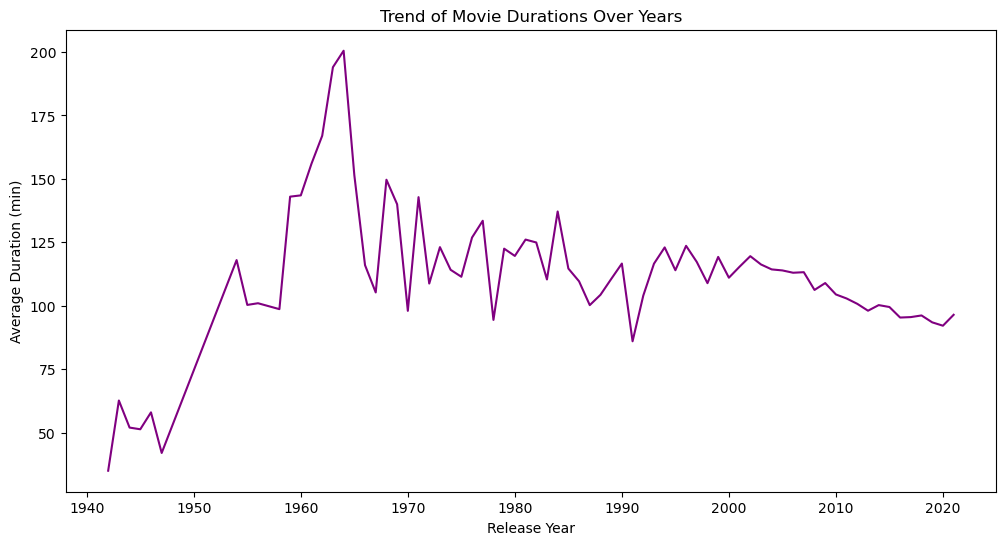

In [82]:
# 17. Trend in movie durations over the years

movie_trends = movies.groupby('release_year')['duration_min'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=movie_trends, x='release_year', y='duration_min', color='purple')
plt.title('Trend of Movie Durations Over Years')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (min)')
plt.show()

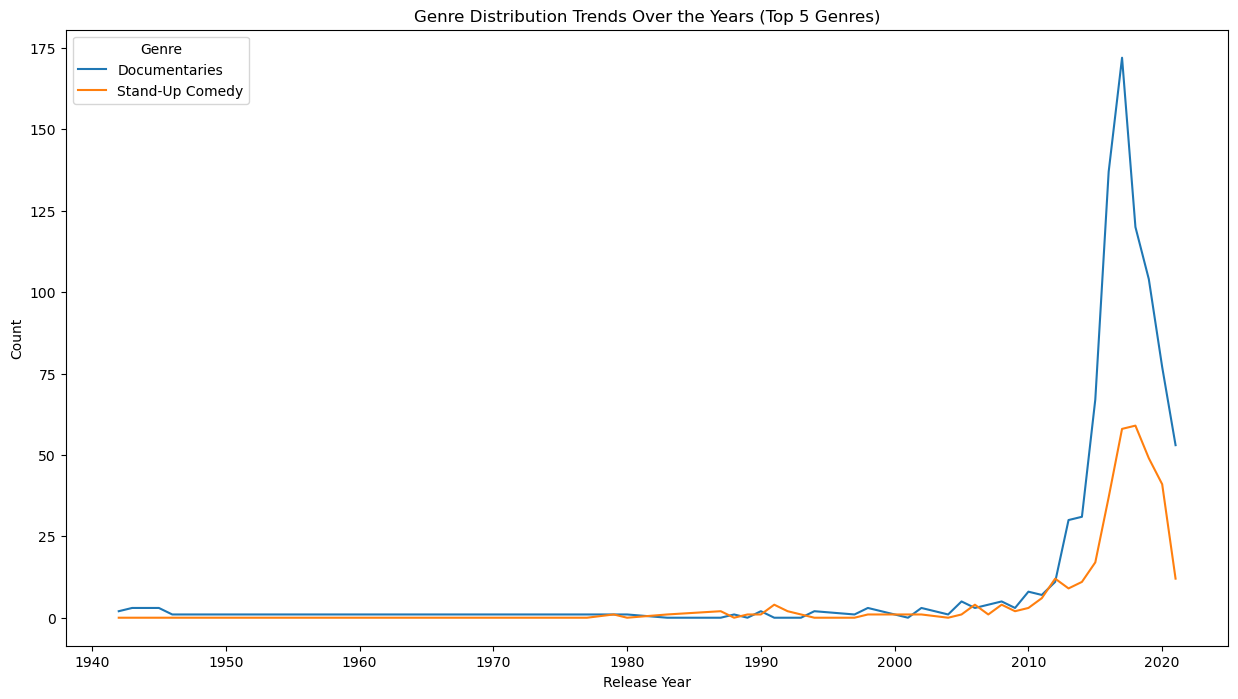

In [83]:
# 5) Content Launch Strategy

# 18. Months with most content added

top_5_genres = data_['listed_in'].value_counts().head(5).index
genre_year_trend = data_[['release_year', 'listed_in']]
genre_year_trend = genre_year_trend.assign(listed_in=genre_year_trend['listed_in'].str.split(', ')).explode('listed_in')
genre_year_trend = genre_year_trend[genre_year_trend['listed_in'].isin(top_5_genres)]
genre_year_pivot = genre_year_trend.groupby(['release_year', 'listed_in']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 8))
genre_year_pivot.plot(kind='line', ax=plt.gca())
plt.title('Genre Distribution Trends Over the Years (Top 5 Genres)')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.legend(title='Genre')
plt.show()

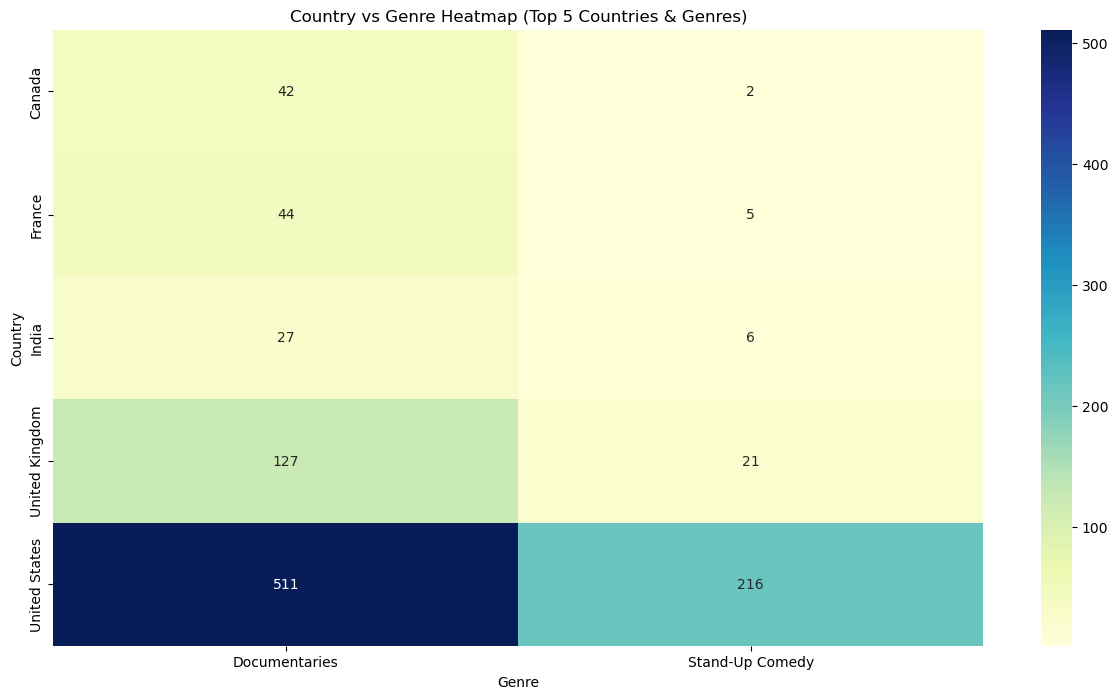

In [84]:
# 20. Countries producing most content in each genre
# Focus on Top 5 Genres and Top 5 Countries
country_genre = data_[['country', 'listed_in']].dropna()
country_genre = country_genre.assign(country=country_genre['country'].str.split(', ')).explode('country')
country_genre = country_genre.assign(listed_in=country_genre['listed_in'].str.split(', ')).explode('listed_in')

top_5_countries = countries.value_counts().head(5).index
country_genre_filtered = country_genre[country_genre['listed_in'].isin(top_5_genres) & country_genre['country'].isin(top_5_countries)]
country_genre_pivot = country_genre_filtered.groupby(['country', 'listed_in']).size().unstack(fill_value=0)


plt.figure(figsize=(15, 8))
sns.heatmap(country_genre_pivot, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Country vs Genre Heatmap (Top 5 Countries & Genres)')
plt.xlabel('Genre')
plt.ylabel('Country')
plt.show()